## Model calibration and validation
Following Ballestra et al. 2020 approach the task is separated into two: 
1. calibrate a CIR model to observed ZCB prices (proxied by available market data);
2. calibrate the CE model to observed CDS spreads, taking the CIR model as input.

The initial calibration is done on the initial date from the sample data. The most efficient model is kept for historical calibration throughout the entire sample. The last calibrated parameters are used in the validation for the test period. 

In [1]:
import pandas as pd
import numpy as np
from src.cir_calibration import CIR_calibration, CIR_plot, bond_price_CIR
from src.helper import MAPE
from src.ce_b_price import CEb_calibration

## CIR calibration



In [2]:
int_rate = pd.read_excel("data/Spot-Yield-Curve-Analysis_01-01-2015_FACTSET.xlsx", sheet_name='SpotCurve')
int_rate = int_rate[1:122] #from 1M to 10Y 1M 
int_rate['SPOTTRYUS-FDS'] = int_rate['SPOTTRYUS-FDS'].astype('float')
int_rate.tail(10)

,Tenor,SPOTTRYUS-FDS
112,9Y 4M,2.190349
113,9Y 5M,2.195020
114,9Y 6M,2.199495
115,9Y 7M,2.204081
116,9Y 8M,2.208641
117,9Y 9M,2.213033
118,9Y 10M,2.217551
119,9Y 11M,2.221903
120,10Y,2.226381
121,10Y 1M,2.230850


In [3]:
#Convert Tenor to Year fractions
tenor = pd.DataFrame(int_rate['Tenor'].str.extract(pat = r'(\d*)(\w.*)', expand=True))
tenor = pd.concat([tenor, tenor[1].str.extract(pat = r'(\D*)(\d*)', expand=True)], axis=1)
tenor.iloc[:,3] = tenor.iloc[:,3].replace('', 0)
int_rate.loc[:,'y_frac'] = tenor.iloc[:,0].astype('float') + tenor.iloc[:,3].astype('float')/12
int_rate.loc[:11,'y_frac'] = int_rate['y_frac'][:11]/12 #first 11 rows are in months
int_rate.tail(10)

,Tenor,SPOTTRYUS-FDS,y_frac
112,9Y 4M,2.190349,9.333333
113,9Y 5M,2.195020,9.416667
114,9Y 6M,2.199495,9.500000
115,9Y 7M,2.204081,9.583333
116,9Y 8M,2.208641,9.666667
117,9Y 9M,2.213033,9.750000
118,9Y 10M,2.217551,9.833333
119,9Y 11M,2.221903,9.916667
120,10Y,2.226381,10.000000
121,10Y 1M,2.230850,10.083333


In [4]:
int_rate.describe()

,SPOTTRYUS-FDS,y_frac
count,121.000000,121.000000
mean,1.466894,5.083333
std,0.690401,2.922811
min,0.049399,0.083333
25%,0.949253,2.583333
50%,1.699102,5.083333
75%,2.065935,7.583333
max,2.230850,10.083333


In [5]:
# converting to bond prices, assuming continuous compounding
price = np.exp(-int_rate['SPOTTRYUS-FDS']/100*int_rate['y_frac']) #dividing by 100 bc expressed in %
int_rate.loc[:,'market_price'] = price
int_rate.head(10)


,Tenor,SPOTTRYUS-FDS,y_frac,market_price
1,1M,0.049399,0.083333,0.999959
2,2M,0.067208,0.166667,0.999888
3,3M,0.087299,0.250000,0.999782
4,4M,0.107162,0.333333,0.999643
5,5M,0.128173,0.416667,0.999466
6,6M,0.149027,0.500000,0.999255
7,7M,0.171164,0.583333,0.999002
8,8M,0.193954,0.666667,0.998708
9,9M,0.216678,0.750000,0.998376
10,10M,0.240905,0.833333,0.997994


In [6]:
glob_cir, cir = CIR_calibration(int_rate.market_price, int_rate.y_frac) # first runs a global opt then tries local opt with the found params
print(glob_cir)
print(cir)

       Global Optimization
a             3.789218e-01
b             3.045474e-02
r0            1.271423e-08
sigma         3.963717e-05
       Local optimization
a            3.789962e-01
b            3.045155e-02
r0           1.176028e-08
sigma        4.211329e-05


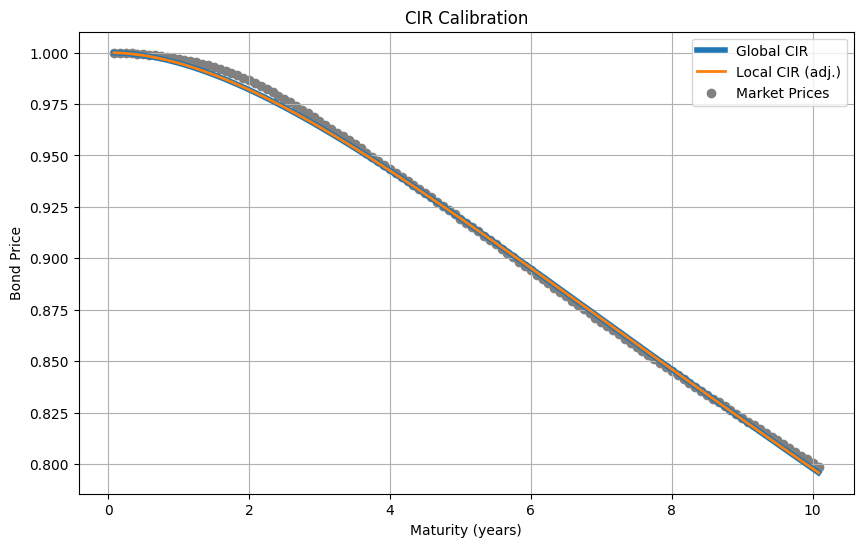

In [7]:
CIR_plot(int_rate, glob_cir.values.flatten(), cir.values.flatten()) ######### factset yield curve comes from interna, model

In [8]:
k, mu, r0, sigma_r = cir.values.flatten()
MAPE_bond = MAPE(int_rate.market_price, bond_price_CIR(k,mu,r0,sigma_r,int_rate.y_frac))
print(f'MAPE_bond = {MAPE_bond*100}%')

MAPE_bond = 0.17783895202203637%


In [9]:
# Historical calibration (2015-2019)

## CEb Model calibration

In [10]:
cds_bps = pd.read_csv("data/cleaned_cds_with_ratings.csv")
cds_bps.head()
cds = cds_bps.copy() # deepcopy
cds[['PX1','PX2','PX3','PX4','PX5','PX6','PX7','PX8','PX9','PX10']] = cds[['PX1','PX2','PX3','PX4','PX5','PX6','PX7','PX8','PX9','PX10']]/10000
cds.head()

,date,month,year,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10,YearlyRating
0,2015-01-01,1,2015,AAPL,Apple Inc,0.000830,0.001110,0.001290,0.001680,0.002360,0.003180,0.003670,0.004280,0.004760,0.005160,Low Risk
1,2015-01-02,1,2015,AAPL,Apple Inc,0.000830,0.001110,0.001290,0.001680,0.002360,0.003181,0.003670,0.004280,0.004760,0.005160,Low Risk
2,2015-01-05,1,2015,AAPL,Apple Inc,0.000954,0.001280,0.001489,0.001941,0.002729,0.003652,0.004186,0.004845,0.005356,0.005777,Low Risk
3,2015-01-06,1,2015,AAPL,Apple Inc,0.000782,0.001045,0.001214,0.001582,0.002223,0.003011,0.003491,0.004091,0.004567,0.004967,Low Risk
4,2015-01-07,1,2015,AAPL,Apple Inc,0.000784,0.001048,0.001218,0.001586,0.002230,0.003022,0.003503,0.004106,0.004585,0.004986,Low Risk


In [11]:
# 01-01-2015 calibration on one entity
single_entity = cds.loc[(cds.date =='2015-01-01') & (cds.ticker == 'AAPL')]
maturities = np.linspace(1,10,10)

CEb_calibration(cir.values.flatten(),0.4,single_entity[['PX1','PX2','PX3','PX4','PX5','PX6','PX7','PX8','PX9','PX10']].values,maturities)

#33sec x 114 entities 


/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in 

(         Local Optimization
 x_ratio            2.281691
 alpha              0.178048
 sigma_x            0.296127,
          Global Optimization
 x_ratio             2.270000
 alpha               0.162632
 sigma_x             0.289474)

In [12]:
# all entities --> runtimewarning coming from unavab model_prices (sigma too small?)
date = '2015-01-01'
cds_date = cds.loc[cds.date == date]
maturities = np.linspace(1, 10, 10)
rec_rate = 0.4
tickers = cds_date['ticker'].unique()

results = []

for ticker in tickers[0:10]: # slow 

    single_entity = cds_date.loc[cds_date.ticker == ticker]
    market_prices = single_entity[['PX1','PX2','PX3','PX4','PX5','PX6','PX7','PX8','PX9','PX10']]

    params, params_brute = CEb_calibration(
        cir.values.flatten(),
        rec_rate,
        market_prices.values,
        maturities) # final results are in the first element of the tuple
    
    params['ticker'] = ticker
    results.append(params)
results

/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))
/Users/linaatanasova/Documents/pycourse/qfi/thesis_code/src/helper.py:11: RuntimeWarning: divide by zero encountered in 

[         Local Optimization ticker
 x_ratio            2.281691   AAPL
 alpha              0.178048   AAPL
 sigma_x            0.296127   AAPL,
          Local Optimization ticker
 x_ratio            4.378473    ADM
 alpha              0.272139    ADM
 sigma_x            0.501304    ADM,
          Local Optimization ticker
 x_ratio            2.492531   AMAT
 alpha              0.164221   AMAT
 sigma_x            0.359063   AMAT,
          Local Optimization ticker
 x_ratio            4.576831   AMGN
 alpha              0.285503   AMGN
 sigma_x            0.500525   AMGN,
          Local Optimization ticker
 x_ratio            2.501787    APD
 alpha              0.146788    APD
 sigma_x            0.314797    APD,
          Local Optimization ticker
 x_ratio            2.925060    AVY
 alpha              0.100511    AVY
 sigma_x            0.397820    AVY,
          Local Optimization ticker
 x_ratio            2.495702    BAX
 alpha              0.192270    BAX
 sigma_x            0.

## HCI Model calibration

## CEa Model calibration

## CE Model calibration

## Validation